# CS464 — Deepfake Detection
**Group 14** | George · Nana · Shaun · Victor

This notebook is the **summary entry point** for the project. Each section imports from the scripts in `../scripts/` and presents results. For full implementation details, refer to the individual scripts.

---
| Section | Script |
|---------|--------|
| 1. Setup & Data | `03_dataloaders.py` |
| 2. Baseline Model | `baseline_cnn.py` + `04_train_baseline.py` |
| 3. Improved Model | `efficientnet.py` + `05_train_efficientnet.py` |
| 4. Evaluation | `06_evaluate.py` |

# 0. Environment Setup

In [1]:
import sys
import os
from pathlib import Path

# Add scripts folder to path so we can import from it
SCRIPTS_DIR = Path('../scripts').resolve()
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

# Key project paths
WORKSPACE_ROOT = Path('../..').resolve()   # workspace/
DATA_DIR       = WORKSPACE_ROOT / 'src' / 'data'
MODELS_DIR     = WORKSPACE_ROOT / 'src' / 'models'

print(f'Workspace : {WORKSPACE_ROOT}')
print(f'Data dir  : {DATA_DIR}')
print(f'Models dir: {MODELS_DIR}')

Workspace : C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace
Data dir  : C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\data
Models dir: C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\models


In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
print(f'MPS available   : {torch.backends.mps.is_available()}')

PyTorch version : 2.11.0+cu128
CUDA available  : True
MPS available   : False


In [3]:
import sys
from pathlib import Path

# A
SCRIPTS_DIR = Path("../../src/scripts").resolve()
sys.path.insert(0, str(SCRIPTS_DIR))

print(f"Scripts dir: {SCRIPTS_DIR}")
print(f"Exists: {SCRIPTS_DIR.exists()}")

Scripts dir: C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\scripts
Exists: True


# Data Loading and Exploration

In [4]:
from dataloaders import get_device, get_dataloaders, sanity_check
device  = get_device()
loaders = get_dataloaders(DATA_DIR, batch_size=32, num_workers=4)

[device] CUDA — NVIDIA GeForce RTX 5050 Laptop GPU  (8.5 GB VRAM)


In [5]:
sanity_check(loaders)

[device] CUDA — NVIDIA GeForce RTX 5050 Laptop GPU  (8.5 GB VRAM)
DATALOADER SANITY CHECK

  [TRAIN]  73391 samples
    fake   (idx=0):    62906 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):    10485 samples   14.3%  ███████

  [VAL]  15750 samples
    fake   (idx=0):    13500 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2250 samples   14.3%  ███████

  [TEST]  15843 samples
    fake   (idx=0):    13578 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2265 samples   14.3%  ███████

  Class weights (for CrossEntropyLoss):
    fake   (idx=0):  weight = 0.5833
    real   (idx=1):  weight = 3.4998

  Fetching one sample batch from train loader...
    images shape  : (32, 3, 224, 224)
    labels shape  : (32,)
    pixel range   : [-2.118, 2.640]
    batch fake    : 14
    batch real    : 18

Sanity check passed. Ready to train.


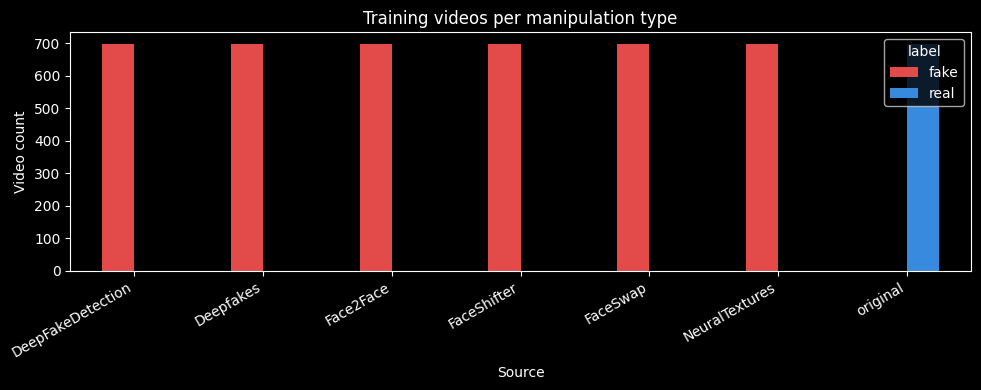

In [5]:
# ── Per-manipulation-type breakdown from train manifest ──────────
manifest = pd.read_csv(DATA_DIR / 'train_manifest.csv')
source_counts = manifest.groupby(['source', 'label']).size().unstack(fill_value=0)

source_counts.plot(kind='bar', figsize=(10, 4), color=['#E24B4A', '#378ADD'])
plt.title('Training videos per manipulation type')
plt.xlabel('Source')
plt.ylabel('Video count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

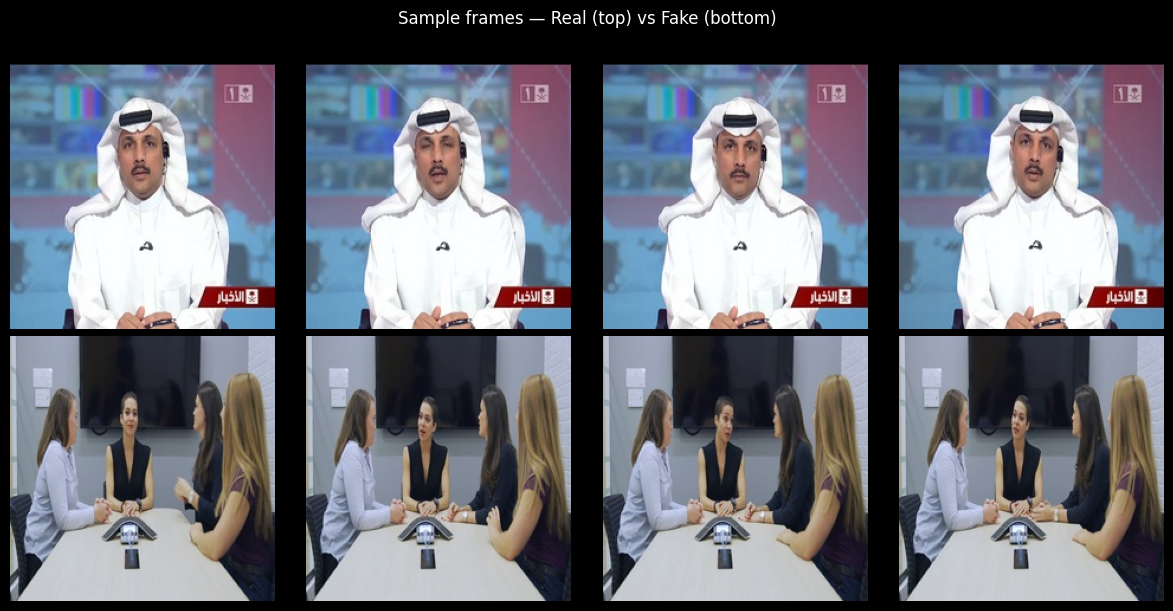

In [6]:
# ── Sample frames: real vs fake side by side ─────────────────────
def show_sample_frames(data_dir: Path, n: int = 4):
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for row, label in enumerate(['real', 'fake']):
        folder = data_dir / 'train' / label
        frames = sorted(folder.glob('*.jpg'))[:n]
        for col, frame_path in enumerate(frames):
            img = mpimg.imread(frame_path)
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if col == 0:
                axes[row][col].set_ylabel(label.upper(), fontsize=12, fontweight='bold')
    plt.suptitle('Sample frames — Real (top) vs Fake (bottom)', y=1.01)
    plt.tight_layout()
    plt.show()

show_sample_frames(DATA_DIR)

# Baseline Model

A simple 4-block CNN with Global Average Pooling. No pretrained weights.


In [7]:
from baseline_cnn import get_baseline_model

baseline = get_baseline_model().to(device)

total_params    = sum(p.numel() for p in baseline.parameters())
trainable       = sum(p.numel() for p in baseline.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable:,}')
print()
print(baseline)

Total parameters     : 422,050
Trainable parameters : 422,050

BaselineCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, 

In [8]:
# ── Train the baseline ───────────────────────────────────────────
# This cell calls the training script directly.
# Progress will print below. Estimated time: 5-10 min/epoch on RTX 5050.
# To resume from a checkpoint, pass resume_path to train().

from train_baseline import train as train_baseline

train_baseline(resume_path=None)

[device] CUDA — NVIDIA GeForce RTX 5050 Laptop GPU  (8.5 GB VRAM)
DATALOADER SANITY CHECK

  [TRAIN]  73391 samples
    fake   (idx=0):    62906 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):    10485 samples   14.3%  ███████

  [VAL]  15750 samples
    fake   (idx=0):    13500 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2250 samples   14.3%  ███████

  [TEST]  15843 samples
    fake   (idx=0):    13578 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2265 samples   14.3%  ███████

  Class weights (for CrossEntropyLoss):
    fake   (idx=0):  weight = 0.5833
    real   (idx=1):  weight = 3.4998

  Fetching one sample batch from train loader...
    images shape  : (32, 3, 224, 224)
    labels shape  : (32,)
    pixel range   : [-2.118, 2.640]
    batch fake    : 17
    batch real    : 15

Sanity check passed. Ready to train.

Model: BaselineCNN  (422,050 parameters)

Training Basel

Epoch   1/20 | train_loss=0.4281  train_acc=0.5068 | val_loss=1.3537  val_acc=0.1926  val_auc=0.4328 | lr=1.00e-03  (173s)
  New best model saved  (val_loss=1.3537)


Epoch   2/20 | train_loss=0.4098  train_acc=0.5254 | val_loss=1.3247  val_acc=0.2286  val_auc=0.4216 | lr=1.00e-03  (167s)
  New best model saved  (val_loss=1.3247)


Epoch   3/20 | train_loss=0.3973  train_acc=0.5450 | val_loss=1.4659  val_acc=0.2740  val_auc=0.4191 | lr=1.00e-03  (185s)


Epoch   4/20 | train_loss=0.3960  train_acc=0.5491 | val_loss=1.4951  val_acc=0.2309  val_auc=0.4198 | lr=1.00e-03  (269s)


Epoch   5/20 | train_loss=0.3909  train_acc=0.5590 | val_loss=1.5133  val_acc=0.2519  val_auc=0.4155 | lr=1.00e-03  (211s)


Epoch   6/20 | train_loss=0.3856  train_acc=0.5639 | val_loss=1.4873  val_acc=0.2757  val_auc=0.4182 | lr=1.00e-03  (186s)


Epoch   7/20 | train_loss=0.3816  train_acc=0.5700 | val_loss=1.5118  val_acc=0.2725  val_auc=0.4153 | lr=5.00e-04  (183s)


Epoch   8/20 | train_loss=0.3807  train_acc=0.5713 | val_loss=1.5160  val_acc=0.2710  val_auc=0.4144 | lr=5.00e-04  (183s)


Epoch   9/20 | train_loss=0.3802  train_acc=0.5720 | val_loss=1.4858  val_acc=0.2830  val_auc=0.4156 | lr=5.00e-04  (181s)

Early stopping — no improvement for 7 epochs.

Training complete.
  Best checkpoint : C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\models\baseline_cnn_best.pth
  Training log    : C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\models\baseline_training_log.csv


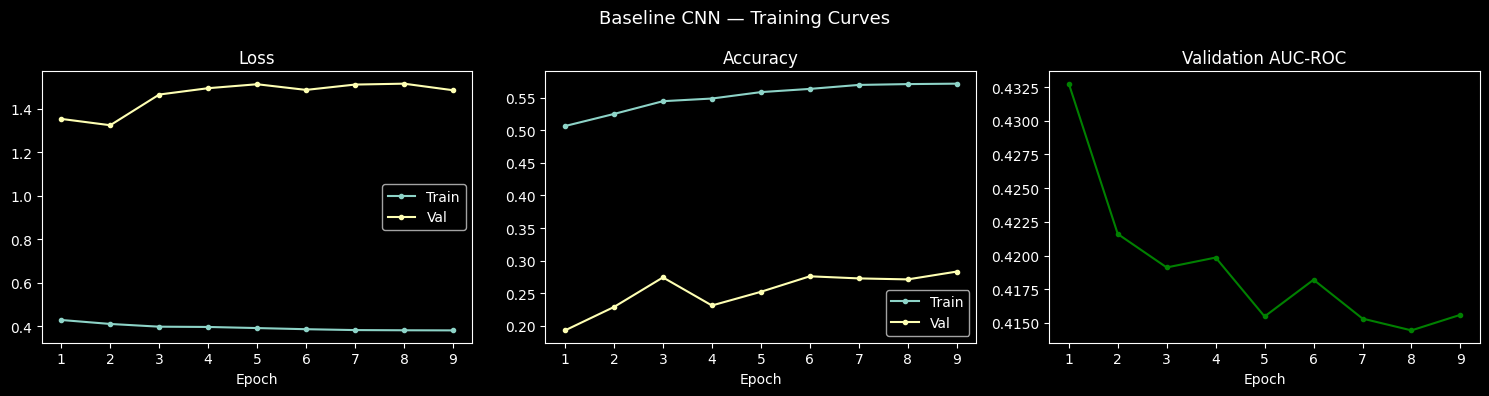

Best val AUC  : 0.4328  (epoch 1)
Best val loss : 1.3247


In [10]:
# ── Plot baseline training curves ───────────────────────────────
log = pd.read_csv(MODELS_DIR / 'baseline_training_log.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].plot(log['epoch'], log['train_loss'], label='Train', marker='o', markersize=3)
axes[0].plot(log['epoch'], log['val_loss'],   label='Val',   marker='o', markersize=3)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(log['epoch'], log['train_acc'], label='Train', marker='o', markersize=3)
axes[1].plot(log['epoch'], log['val_acc'],   label='Val',   marker='o', markersize=3)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(log['epoch'], log['val_auc'], color='green', marker='o', markersize=3)
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')

plt.suptitle('Baseline CNN — Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Best val AUC  : {log['val_auc'].max():.3f}  (epoch {log['val_auc'].idxmax()+1})")
print(f"Best val loss : {log['val_loss'].min():.3f}")

# Advanced Models

## Transfer Learning with EfficientNet

In [5]:
from efficientnet import get_efficientnet, freeze_backbone, unfreeze_backbone
from train_efficientnet import train as train_efficientnet

model = get_efficientnet().to(device)
train_efficientnet(start_phase=1)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Timmy/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:06<00:00, 3.10MB/s]


[device] CUDA — NVIDIA GeForce RTX 5050 Laptop GPU  (8.5 GB VRAM)
DATALOADER SANITY CHECK

  [TRAIN]  73391 samples
    fake   (idx=0):    62906 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):    10485 samples   14.3%  ███████

  [VAL]  15750 samples
    fake   (idx=0):    13500 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2250 samples   14.3%  ███████

  [TEST]  15843 samples
    fake   (idx=0):    13578 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2265 samples   14.3%  ███████

  Class weights (for CrossEntropyLoss):
    fake   (idx=0):  weight = 0.5833
    real   (idx=1):  weight = 3.4998

  Fetching one sample batch from train loader...
    images shape  : (32, 3, 224, 224)
    labels shape  : (32,)
    pixel range   : [-2.118, 2.640]
    batch fake    : 21
    batch real    : 11

Sanity check passed. Ready to train.

Model: EfficientNet-B0  (4,335,998 total parameters)
[Ph

  Epoch  1/10 | train_loss=0.3957  train_acc=0.5636 | val_loss=1.3374  val_acc=0.2894  val_auc=0.3823 | lr=1.00e-03  (184s)
  Checkpoint saved → efficientnet_phase1_best.pth
  ✓ New best  (val_loss=1.3374  val_auc=0.3823)


  Epoch  2/10 | train_loss=0.3806  train_acc=0.5744 | val_loss=1.3132  val_acc=0.2875  val_auc=0.3698 | lr=1.00e-03  (176s)
  Checkpoint saved → efficientnet_phase1_best.pth
  ✓ New best  (val_loss=1.3132  val_auc=0.3698)


...

  Epoch  7/15 | train_loss=0.2968  train_acc=0.6651 | val_loss=1.4670  val_acc=0.4035  val_auc=0.2336 | lr=5.00e-06  (177s)


  Epoch  8/15 | train_loss=0.2886  train_acc=0.6748 | val_loss=1.5038  val_acc=0.4063  val_auc=0.2309 | lr=5.00e-06  (188s)


  Epoch  9/15 | train_loss=0.2882  train_acc=0.6771 | val_loss=1.4776  val_acc=0.4127  val_auc=0.2235 | lr=5.00e-06  (187s)


  Epoch 10/15 | train_loss=0.2800  train_acc=0.6861 | val_loss=1.5324  val_acc=0.4123  val_auc=0.2195 | lr=2.50e-06  (187s)


  Epoch 11/15 | train_loss=0.2772  train_acc=0.6924 | val_loss=1.4998  val_acc=0.4208  val_auc=0.2207 | lr=2.50e-06  (192s)

  Early stopping — no improvement for 5 epochs.

Phase 2 complete.
  Best val_loss=1.4465  val_auc=0.2313

EfficientNet training complete.
  Use for evaluation: efficientnet_phase2_best.pth
  Training log:       C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\models\efficientnet_training_log.csv

Next step: run 06_evaluate.py to compare both models on the test set.


In [ ]:
log = pd.read_csv(MODELS_DIR / 'efficientnet_training_log.csv')

for phase_num in [1, 2]:
    phase_log = log[log['phase'] == phase_num]
    print(f"Phase {phase_num} — best val_auc: {phase_log['val_auc'].max():.4f}")

## Vit Model

In [5]:

from vit_model import get_vit_model, freeze_backbone, unfreeze_backbone

vit_model = get_vit_model().to(device)

total_params    = sum(p.numel() for p in vit_model.parameters())
trainable       = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)

print(f'Model: ViT-B/16')
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable:,}')
print()

# Show what freezing does
print('Phase 1 (head only):')
freeze_backbone(vit_model)
print()

print('Phase 2 (full fine-tune):')
unfreeze_backbone(vit_model)

Model: ViT-B/16
Total parameters     : 85,800,194
Trainable parameters : 85,800,194

Phase 1 (head only):
[Phase 1] Backbone FROZEN — trainable: 1,538 / 85,800,194 parameters (0.0%)

Phase 2 (full fine-tune):
[Phase 2] Backbone UNFROZEN — trainable: 85,800,194 / 85,800,194 parameters (100.0%)


In [6]:
# Import the training function
import sys
sys.path.insert(0, str(SCRIPTS_DIR))

from train_vit import train as train_vit

# Run two-phase training
# This will take longer than EfficientNet due to the larger model size
# Estimated: 15-20 min/epoch on RTX 5050 at batch_size=16
train_vit(start_phase=1)

[device] CUDA — NVIDIA GeForce RTX 5050 Laptop GPU  (8.5 GB VRAM)
DATALOADER SANITY CHECK

  [TRAIN]  73391 samples
    fake   (idx=0):    62906 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):    10485 samples   14.3%  ███████

  [VAL]  15750 samples
    fake   (idx=0):    13500 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2250 samples   14.3%  ███████

  [TEST]  15843 samples
    fake   (idx=0):    13578 samples   85.7%  ██████████████████████████████████████████
    real   (idx=1):     2265 samples   14.3%  ███████

  Class weights (for CrossEntropyLoss):
    fake   (idx=0):  weight = 0.5833
    real   (idx=1):  weight = 3.4998

  Fetching one sample batch from train loader...
    images shape  : (16, 3, 224, 224)
    labels shape  : (16,)
    pixel range   : [-2.118, 2.640]
    batch fake    : 7
    batch real    : 9

Sanity check passed. Ready to train.

Model: ViT-B/16  (85,800,194 total parameters)

[Phase 1] 

  Epoch  1/10 | train_loss=0.4076  train_acc=0.5785 | val_loss=1.6447  val_acc=0.2902  val_auc=0.3778 | lr=1.00e-03  (334s)
  Checkpoint saved → vit_phase1_best.pth
  ✓ New best  (val_loss=1.6447  val_auc=0.3778)


  Epoch  2/10 | train_loss=0.4000  train_acc=0.5819 | val_loss=1.4538  val_acc=0.2928  val_auc=0.3704 | lr=1.00e-03  (333s)
  Checkpoint saved → vit_phase1_best.pth
  ✓ New best  (val_loss=1.4538  val_auc=0.3704)


  Epoch  3/10 | train_loss=0.3957  train_acc=0.5847 | val_loss=1.4993  val_acc=0.3107  val_auc=0.3736 | lr=1.00e-03  (337s)


  Epoch  4/10 | train_loss=0.3962  train_acc=0.5839 | val_loss=1.5807  val_acc=0.2878  val_auc=0.3650 | lr=1.00e-03  (332s)


...

  Epoch 11/15 | train_loss=0.1656  train_acc=0.8448 | val_loss=0.9819  val_acc=0.6693  val_auc=0.1881 | lr=1.00e-05  (788s)


  Epoch 12/15 | train_loss=0.1399  train_acc=0.8713 | val_loss=0.8669  val_acc=0.7047  val_auc=0.1952 | lr=5.00e-06  (784s)
  Checkpoint saved → vit_phase2_best.pth
  ✓ New best  (val_loss=0.8669  val_auc=0.1952)


  Epoch 13/15 | train_loss=0.1287  train_acc=0.8817 | val_loss=0.9923  val_acc=0.6990  val_auc=0.1936 | lr=5.00e-06  (781s)


  Epoch 14/15 | train_loss=0.1214  train_acc=0.8898 | val_loss=1.1826  val_acc=0.6660  val_auc=0.1952 | lr=5.00e-06  (785s)


  Epoch 15/15 | train_loss=0.1197  train_acc=0.8913 | val_loss=1.0822  val_acc=0.6978  val_auc=0.1906 | lr=5.00e-06  (767s)

Phase 2 complete.
  Best val_loss=0.8669

ViT-B/16 training complete.
  Best checkpoint : C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\models\vit_phase2_best.pth
  Training log    : C:\Users\Timmy\OneDrive - Ashesi University\Year 3 Sem 2\Deep Learning\Final Project\Final Project A\workspace\src\models\vit_training_log.csv
Next step: run evaluation to compare all three models on the test set.


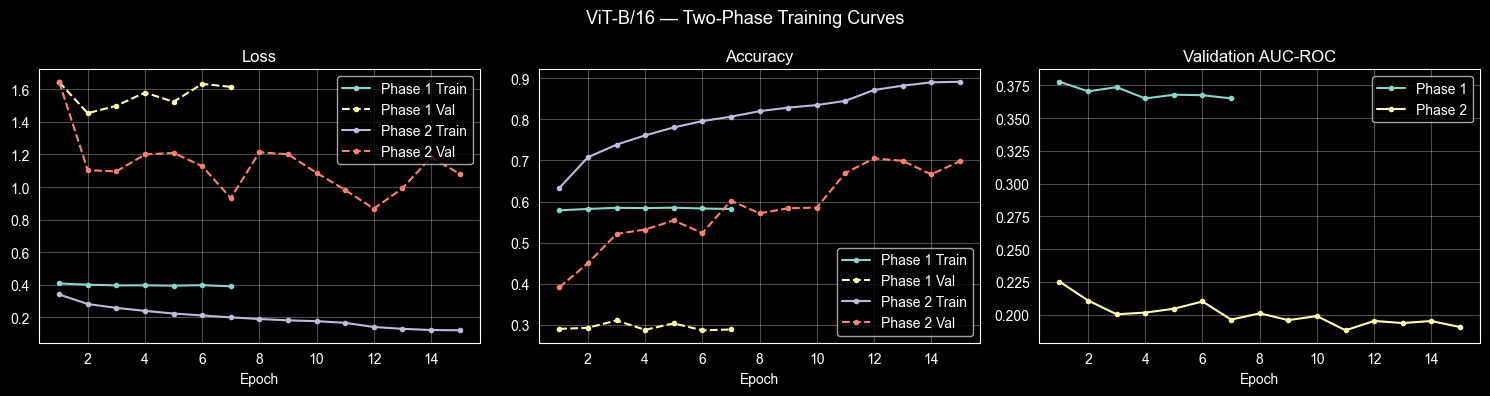

Phase 1 (head only) — best val_auc: 0.3778
Phase 2 (full fine-tune) — best val_auc: 0.2253
Improvement from fine-tuning: -0.1525


In [7]:
log = pd.read_csv(MODELS_DIR / 'vit_training_log.csv')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
for phase_num in [1, 2]:
    phase_log = log[log['phase'] == phase_num]
    label = f'Phase {phase_num}'
    axes[0].plot(phase_log['epoch'], phase_log['train_loss'],
                 label=f'{label} Train', marker='o', markersize=3)
    axes[0].plot(phase_log['epoch'], phase_log['val_loss'],
                 label=f'{label} Val', marker='o', markersize=3, linestyle='--')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
for phase_num in [1, 2]:
    phase_log = log[log['phase'] == phase_num]
    label = f'Phase {phase_num}'
    axes[1].plot(phase_log['epoch'], phase_log['train_acc'],
                 label=f'{label} Train', marker='o', markersize=3)
    axes[1].plot(phase_log['epoch'], phase_log['val_acc'],
                 label=f'{label} Val', marker='o', markersize=3, linestyle='--')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

# AUC-ROC
for phase_num in [1, 2]:
    phase_log = log[log['phase'] == phase_num]
    axes[2].plot(phase_log['epoch'], phase_log['val_auc'],
                 label=f'Phase {phase_num}', marker='o', markersize=3)
axes[2].set_title('Validation AUC-ROC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('ViT-B/16 — Two-Phase Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

# Best metrics
phase1_best_auc = log[log['phase'] == 1]['val_auc'].max()
phase2_best_auc = log[log['phase'] == 2]['val_auc'].max()

print(f"Phase 1 (head only) — best val_auc: {phase1_best_auc:.4f}")
print(f"Phase 2 (full fine-tune) — best val_auc: {phase2_best_auc:.4f}")
print(f"Improvement from fine-tuning: {phase2_best_auc - phase1_best_auc:+.4f}")

# Perfomance Testing and Evaluation

In [9]:
import sys
import pandas as pd
import numpy as np
import torch
import matplotlib.patches as mpatches
from sklearn.metrics import ConfusionMatrixDisplay

from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

sys.path.insert(0, str(SCRIPTS_DIR))

from dataloaders import get_dataloaders, get_device
from baseline_cnn import get_baseline_model
from efficientnet import get_efficientnet
from xception import get_xception
from frequency_cnn import get_frequency_cnn, FrequencyTransform
from evaluate import run_inference, compute_metrics


# ── Setup ────────────────────────────────────────────────────────
device      = get_device()
loaders     = get_dataloaders(DATA_DIR, batch_size=32, num_workers=4)
test_loader = loaders["test"]

MODELS_DIR = WORKSPACE_ROOT / "src" / "models"


# ── Model registry (ONE unified registry) ─────────────────────────
model_registry = [
    ("Baseline CNN",    "baseline_cnn_best.pth",        get_baseline_model, False),
    ("EfficientNet-B0", "efficientnet_phase2_best.pth", get_efficientnet, False),
    ("Xception",        "xception_best.pth",            get_xception, False),
    ("Frequency CNN",   "frequencycnn_best.pth",        get_frequency_cnn, True),
    ("ViT-B/16",        "vit_phase2_best.pth",          get_vit_model, False),  # ← add this
]


# ── Run evaluation ────────────────────────────────────────────────
results = []

for name, ckpt_file, model_fn, needs_freq_loader in model_registry:

    ckpt_path = MODELS_DIR / ckpt_file
    if not ckpt_path.exists():
        print(f"[SKIP] {name} — {ckpt_file} not found")
        continue

    # pick correct loader
    if needs_freq_loader:
        transform = FrequencyTransform()
        dataset = ImageFolder(DATA_DIR / "test", transform=transform)

        loader = DataLoader(
            dataset,
            batch_size=32,
            shuffle=False,
            num_workers=4
        )

        class_to_idx = dataset.class_to_idx
    else:
        loader = test_loader
        class_to_idx = test_loader.dataset.class_to_idx


    # load model
    model = model_fn().to(device)
    ckpt  = torch.load(ckpt_path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]
    elif isinstance(ckpt, dict) and "model" in ckpt:
        state_dict = ckpt["model"]
    else:
        state_dict = ckpt  # checkpoint itself is the state_dict

    model.load_state_dict(state_dict)
    model.eval()

    # inference + metrics
    true_labels, pred_labels, probs = run_inference(model, loader, device)

    metrics = compute_metrics(true_labels, pred_labels, probs, class_to_idx)
    metrics["model"] = name
    results.append(metrics)

    print(f"✓ {name} evaluated")


df = pd.DataFrame(results).set_index("model")
print("\n", df[["accuracy","precision","recall","f1_score","auc_roc"]].round(4))

[device] CUDA — NVIDIA GeForce RTX 5050 Laptop GPU  (8.5 GB VRAM)


✓ Baseline CNN evaluated


✓ EfficientNet-B0 evaluated


✓ Xception evaluated


✓ Frequency CNN evaluated


✓ ViT-B/16 evaluated

                  accuracy  precision  recall  f1_score  auc_roc
model                                                          
Baseline CNN       0.2343     0.9986  0.1067    0.1928   0.5766
EfficientNet-B0    0.4342     0.9718  0.3500    0.5146   0.7536
Xception           0.3018     0.9918  0.1869    0.3146   0.6860
Frequency CNN      0.8570     0.8570  1.0000    0.9230   0.5710
ViT-B/16           0.6870     0.9387  0.6791    0.7881   0.7873


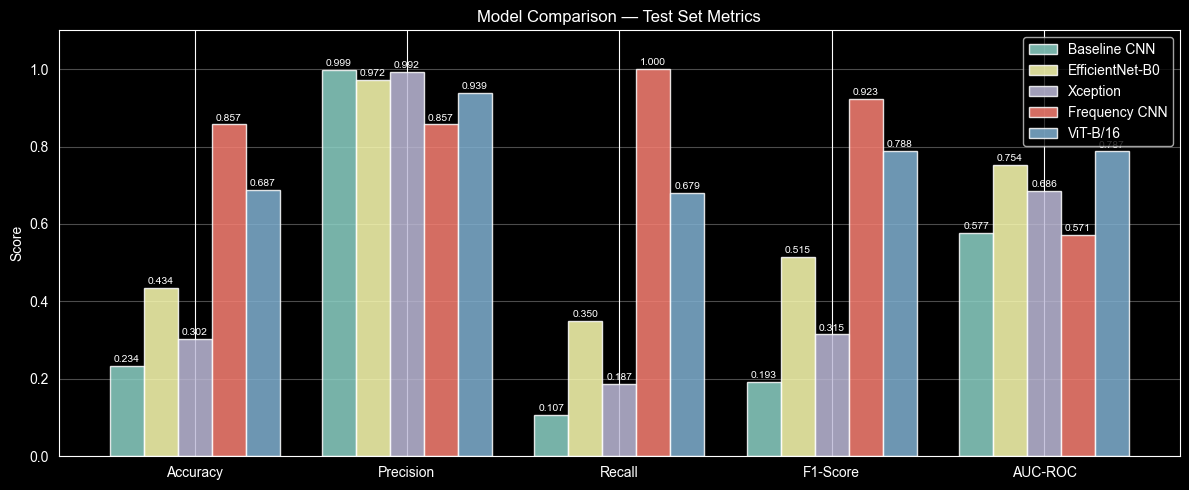

In [10]:
# ── Bar chart comparison ─────────────────────────────────────────
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "auc_roc"]
labels          = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC"]
colors          = ["#2E75B6", "#E8532A", "#4CAF50", "#9C27B0", "#FF9800"]

x   = np.arange(len(metrics_to_plot))
w   = 0.8 / len(df)   # bar width scales with number of models

fig, ax = plt.subplots(figsize=(12, 5))

for i, (model_name, row) in enumerate(df.iterrows()):
    vals   = [row[m] for m in metrics_to_plot]
    offset = (i - len(df) / 2 + 0.5) * w
    bars   = ax.bar(x + offset, vals, w, label=model_name, alpha=0.85)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Test Set Metrics")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

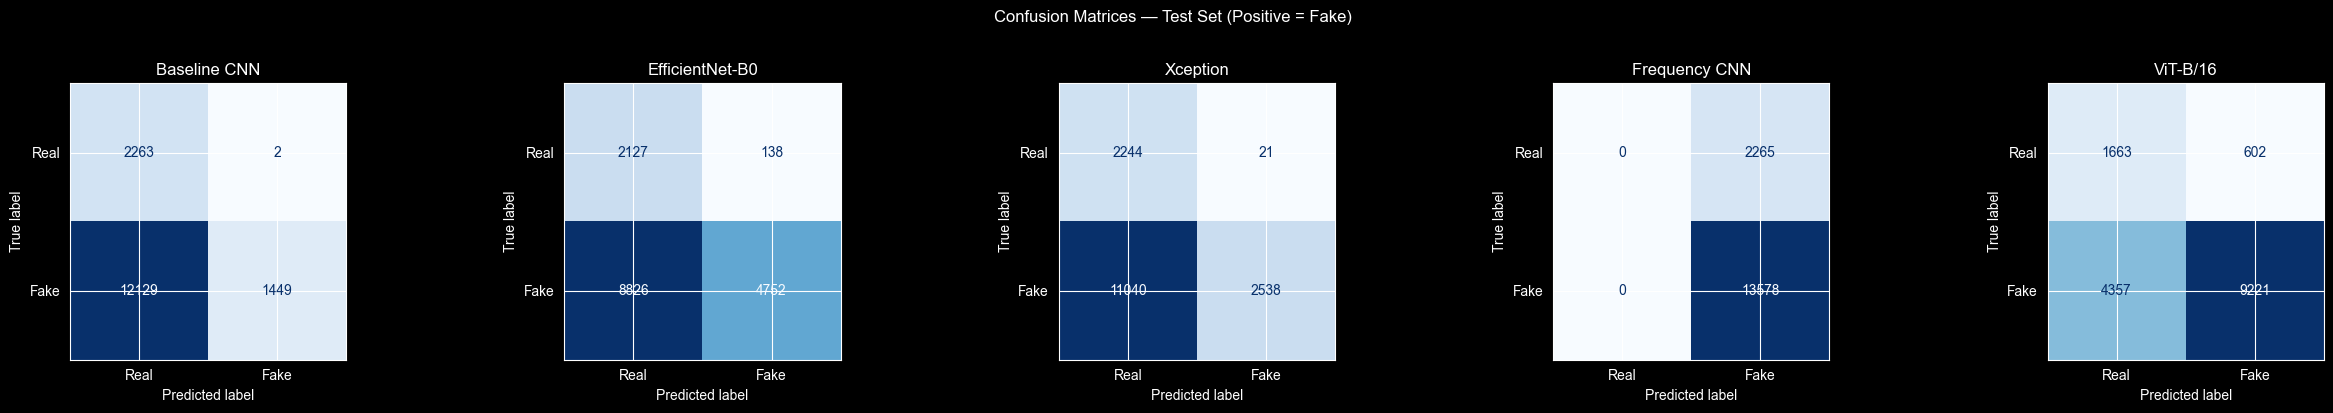

In [11]:
# ── Confusion matrices side by side ──────────────────────────────
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4))

if len(results) == 1:
    axes = [axes]

fake_idx = test_loader.dataset.class_to_idx["fake"]

for ax, r in zip(axes, results):
    cm = np.array([[r["TN"], r["FP"]],
                   [r["FN"], r["TP"]]])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Real", "Fake"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(r["model"])

plt.suptitle("Confusion Matrices — Test Set (Positive = Fake)", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
# ── Summary table ─────────────────────────────────────────────────
display(
    df[["accuracy","precision","recall","f1_score","auc_roc"]]
    .round(4)
    .rename(columns={
        "accuracy":  "Accuracy",
        "precision": "Precision",
        "recall":    "Recall",
        "f1_score":  "F1-Score",
        "auc_roc":   "AUC-ROC",
    })
)

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
model,,,,,
Baseline CNN,0.2343,0.9986,0.1067,0.1928,0.5766
EfficientNet-B0,0.4342,0.9718,0.3500,0.5146,0.7536
Xception,0.3018,0.9918,0.1869,0.3146,0.6860
Frequency CNN,0.8570,0.8570,1.0000,0.9230,0.5710
ViT-B/16,0.6870,0.9387,0.6791,0.7881,0.7873
